In [3]:
import pandas as pd
import os

In [4]:
DATA_DIR = '/kaggle/input/datasets/suvroo/amazon-ml'
IMAGES_DIR = f'{DATA_DIR}/train/images'

train = pd.read_csv(f'{DATA_DIR}/train.csv')
test = pd.read_csv(f'{DATA_DIR}/test.csv')

print("TRAIN:", train.shape, "| TEST:", test.shape)
train.head(3)

TRAIN: (75000, 4) | TEST: (75000, 3)


,sample_id,catalog_content,image_link,price
0,33127,"Item Name: La Victoria Green Taco Sauce Mild, ...",https://m.media-amazon.com/images/I/51mo8htwTH...,4.89
1,198967,"Item Name: Salerno Cookies, The Original Butte...",https://m.media-amazon.com/images/I/71YtriIHAA...,13.12
2,261251,"Item Name: Bear Creek Hearty Soup Bowl, Creamy...",https://m.media-amazon.com/images/I/51+PFEe-w-...,1.97


In [5]:
train['catalog_content'][120]

'Item Name: LorAnn Tropical Punch (Passion Fruit) SS Flavor, 1 dram bottle (.125 fl oz - 3.7ml - 1 teaspoon)\nBullet Point 1: Our Tropical Punch (Passion Fruit) is an exotic, sweet and tangy flavor. Can be added to chocolates for an amazing tropical, fruity flavor.\nBullet Point 2: Our Tropical Punch (Passion Fruit) is an exotic, sweet and tangy flavor. Can be added to chocolates for an amazing tropical, fruity flavor.\nBullet Point 3: A little goes a long way! LorAnn’s super strength flavors are three to four times the strength of typical baking extracts.\nBullet Point 4: A Dram is a small bottle that is the perfect size for 1 batch of homemade Hard Tack Candy (.125 fl oz approximately 1 teaspoon) Love the flavor and need a larger size? Most of the 100+ Super Strength flavors are availble in larger sizes. 1 ounce bottle contains approximately 6 teaspoons. -- 4 ounce bottle contains approximately 24 teaspoons -- 16 ounce and gallon are also available.\nBullet Point 5: Typical uses: har

In [6]:
sample_files = os.listdir(IMAGES_DIR)[:5]
print("Sample files in dir:", sample_files)

print("\nExample image_link:", train['image_link'].iloc[0])
print("Derived filename:", os.path.basename(train['image_link'].iloc[0]))

train['image_filename'] = train['image_link'].apply(lambda x: os.path.basename(str(x)))
test['image_filename'] = test['image_link'].apply(lambda x: os.path.basename(str(x)))

Sample files in dir: ['21ixQ8jLBQL.jpg', '71xunEb3cbL.jpg', '41VRx0XzLGL.jpg', '61AQCAZNF-L.jpg', '814ZQfPAw1L.jpg']

Example image_link: https://m.media-amazon.com/images/I/51mo8htwTHL.jpg
Derived filename: 51mo8htwTHL.jpg


In [7]:
print("=== Missing values (train) ===")
print(train.isnull().sum())
print("\n=== Missing values (test) ===")
print(test.isnull().sum())

print("\nDuplicate rows (train):", train.duplicated().sum())
print("Unique sample_id:", train['sample_id'].nunique(), "/", len(train))

=== Missing values (train) ===
sample_id          0
catalog_content    0
image_link         0
price              0
image_filename     0
dtype: int64

=== Missing values (test) ===
sample_id          0
catalog_content    0
image_link         0
image_filename     0
dtype: int64

Duplicate rows (train): 0
Unique sample_id: 75000 / 75000


count    75000.000000
mean        23.647654
std         33.376932
min          0.130000
25%          6.795000
50%         14.000000
75%         28.625000
max       2796.000000
Name: price, dtype: float64


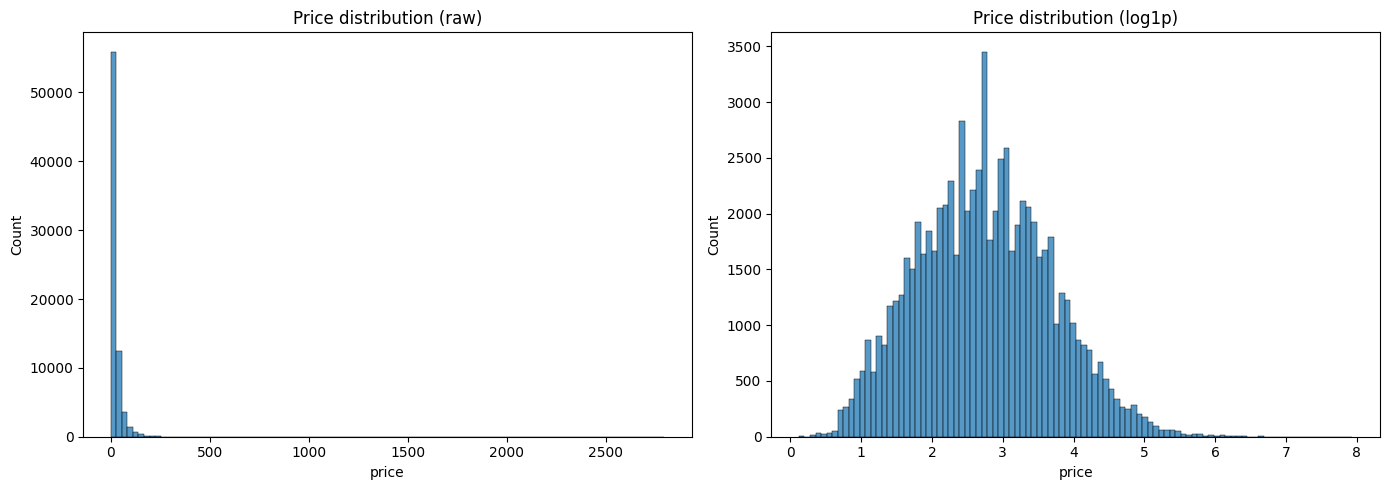


IQR bounds: [-25.95, 61.37]
Outliers: 5524 (7.37%)
Min: 0.13, Max: 2796.0


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print(train['price'].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(train['price'], bins=100, ax=axes[0])
axes[0].set_title('Price distribution (raw)')

sns.histplot(np.log1p(train['price']), bins=100, ax=axes[1])
axes[1].set_title('Price distribution (log1p)')
plt.tight_layout()
plt.show()

Q1, Q3 = train['price'].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
outliers = train[(train['price'] < lower) | (train['price'] > upper)]
print(f"\nIQR bounds: [{lower:.2f}, {upper:.2f}]")
print(f"Outliers: {len(outliers)} ({100*len(outliers)/len(train):.2f}%)")
print(f"Min: {train['price'].min()}, Max: {train['price'].max()}")

       text_len_chars  text_len_words
count    75000.000000    75000.000000
mean       908.886547      147.851693
std        852.896151      137.068731
min         32.000000        7.000000
25%        251.000000       42.000000
50%        643.000000      104.000000
75%       1280.000000      208.000000
max       7894.000000     1333.000000


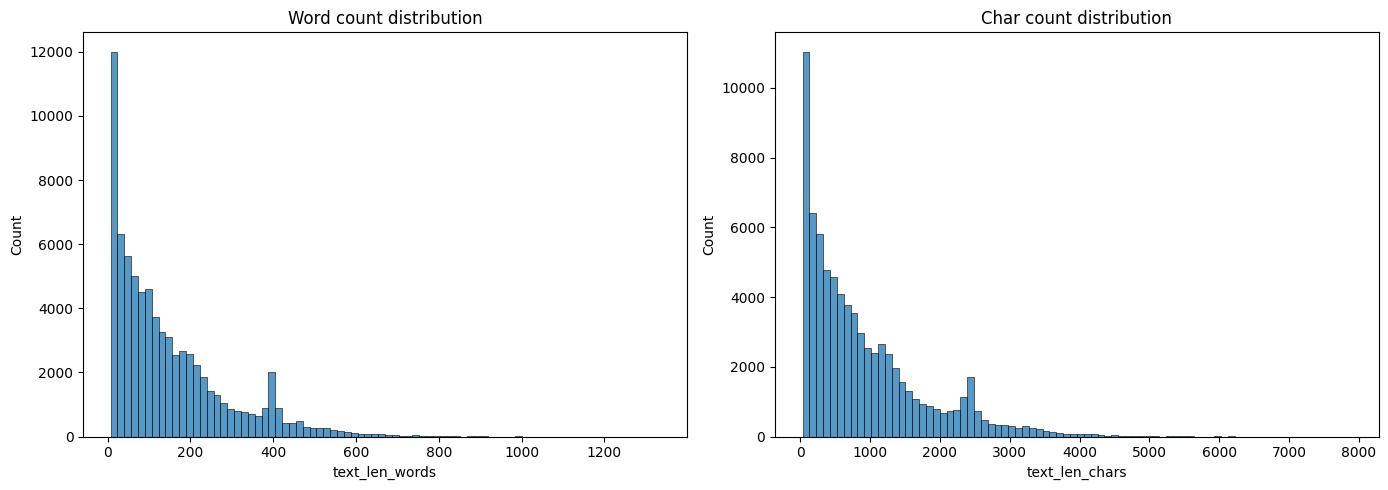


Sample entries:
- Item Name: Log Cabin Sugar Free Syrup, 24 FL OZ (Pack of 12)
Bullet Point 1: Contains twelve (12) 24-ounce bottles of Log Cabin Sugar Free Syrup for Pancakes and Waffles
Bullet Point 2: Indulge in thick, delicious syrup for pancakes, waffles, French toast and more
Bullet Point 3: 90% fewer calories  

- Item Name: Raspberry Ginseng Oolong Tea (50 tea bags, ZIN: 543034) - 2 Pack
Bullet Point 1: Our Raspberry Ginseng Oolong Tea is a luxurious flavored Oolong tea with Raspberries (Red), Raspberry Leaf (Red) and Ginseng Root that you can enjoy hot or cold! The Raspberry Ginseng flavor and aroma is wond 

- Item Name: Walden Farms Honey Dijon Dressing - Calorie-Free, Gluten-Free, Low Carb, Keto-Friendly, Sugar-Free, Sweet Honey & Dijon Mustard Flavor, (12 oz Bottle x 2)
Bullet Point: Walden Farms Salad Dressings
Product Description: Nothing beats the flavor of honey and Dijon mustard, especially when i 



In [9]:
train['text_len_chars'] = train['catalog_content'].astype(str).apply(len)
train['text_len_words'] = train['catalog_content'].astype(str).apply(lambda x: len(x.split()))

print(train[['text_len_chars', 'text_len_words']].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(train['text_len_words'], bins=80, ax=axes[0])
axes[0].set_title('Word count distribution')
sns.histplot(train['text_len_chars'], bins=80, ax=axes[1])
axes[1].set_title('Char count distribution')
plt.tight_layout()
plt.show()

print("\nSample entries:")
for t in train['catalog_content'].sample(3, random_state=42):
    print("-", str(t)[:300], "\n")

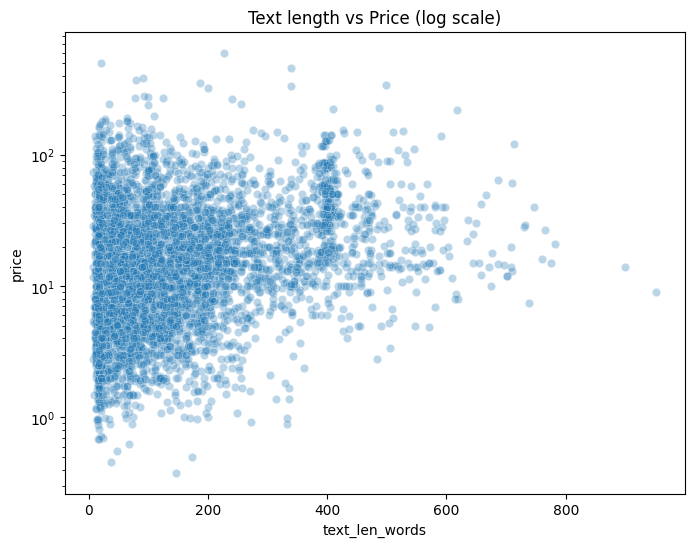

Correlation (word count vs price): 0.14442332594206783
Correlation (word count vs log price): 0.25532815384520047


In [10]:
sample = train.sample(min(5000, len(train)), random_state=42)
fig, ax = plt.subplots(figsize=(8,6))
sns.scatterplot(x='text_len_words', y='price', data=sample, alpha=0.3, ax=ax)
ax.set_yscale('log')
ax.set_title('Text length vs Price (log scale)')
plt.show()

print("Correlation (word count vs price):", train['text_len_words'].corr(train['price']))
print("Correlation (word count vs log price):", train['text_len_words'].corr(np.log1p(train['price'])))

In [11]:
# Check if entries follow a consistent "Item Name: ... " style structure worth parsing later
for t in train['catalog_content'].sample(5, random_state=1):
    print(repr(str(t)[:200]))
    print('---')

# Check for common field markers (Item Name, Pack, Quantity, Value, Unit, Brand etc.)
import re
markers = ['Item Name', 'Pack', 'Quantity', 'Value', 'Unit', 'Brand', 'Description']
for m in markers:
    count = train['catalog_content'].astype(str).str.contains(m, case=False, na=False).sum()
    print(f"'{m}' appears in {count} / {len(train)} rows ({100*count/len(train):.1f}%)")

'Item Name: Dill Rooibos Tea (50 tea bags, ZIN: 532431) - 3 Pack\nBullet Point 1: Our Dill Rooibos Tea is a delightful flavored Rooibos tea with Dill Seeds (Whole) and Dill Weed (California) that you wi'
---
'Item Name: 7 UP A&W Cream Soda Soft Drink, 20-Ounce (Pack of 24)\nBullet Point 1: Cream Soda Flavor: This soft drink has a creamy, sweet flavor with a hint of vanilla.\nBullet Point 2: Light Caffeine Co'
---
'Item Name: Maldon Salt Smoked Sea Salt 125G Bundle Pack Of 2\nValue: 1.0\nUnit: Count\n'
---
'Item Name: D.ivina Organic Pitted Kalamata Olives 6 oz (Pack of 6)\nBullet Point 1: Versatile Use: Ideal as a snack, appetizer, or a flavorful addition to sandwiches, salads, and charcuterie boards.\nBu'
---
'Item Name: Roasted Salted Corn Nuts Snack with Sea Salt by Its Delish (4 lbs)\nBullet Point 1: SCRUMPTIOUS Roasted & Salted Corn Nuts\nBullet Point 2: VALUE SIZE Four Pounds (64 Oz) bulk bag Its Delish '
---
'Item Name' appears in 75000 / 75000 rows (100.0%)
'Pack' appears in 43

In [12]:
from PIL import Image
import random

sample_files = train.sample(300, random_state=42)

missing, corrupt = [], []
for _, row in sample_files.iterrows():
    path = os.path.join(IMAGES_DIR, row['image_filename'])
    if not os.path.exists(path):
        missing.append(row['image_filename'])
        continue
    try:
        img = Image.open(path)
        img.verify()
    except Exception:
        corrupt.append(row['image_filename'])

print(f"Checked {len(sample_files)} images")
print(f"Missing: {len(missing)} ({100*len(missing)/len(sample_files):.1f}%)")
print(f"Corrupt: {len(corrupt)} ({100*len(corrupt)/len(sample_files):.1f}%)")

Checked 300 images
Missing: 0 (0.0%)
Corrupt: 0 (0.0%)


In [13]:
sizes = []
for _, row in train.sample(100, random_state=1).iterrows():
    path = os.path.join(IMAGES_DIR, row['image_filename'])
    if os.path.exists(path):
        try:
            img = Image.open(path)
            sizes.append(img.size)  # (width, height)
        except Exception:
            pass

widths, heights = zip(*sizes)
print(f"Width  - min: {min(widths)}, max: {max(widths)}, mean: {np.mean(widths):.0f}")
print(f"Height - min: {min(heights)}, max: {max(heights)}, mean: {np.mean(heights):.0f}")

Width  - min: 145, max: 2560, mean: 1573
Height - min: 145, max: 2560, mean: 1617


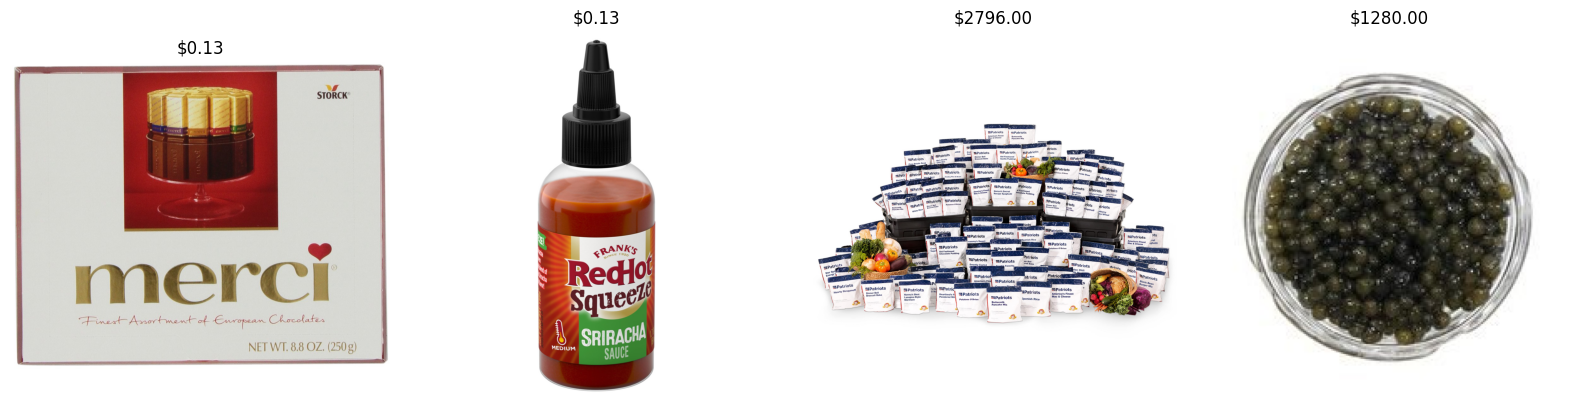

In [14]:
cheap = train.nsmallest(2, 'price')
expensive = train.nlargest(2, 'price')
sample_rows = pd.concat([cheap, expensive])

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (_, row) in zip(axes, sample_rows.iterrows()):
    path = os.path.join(IMAGES_DIR, row['image_filename'])
    try:
        img = Image.open(path)
        ax.imshow(img)
        ax.set_title(f"${row['price']:.2f}")
        ax.axis('off')
    except Exception:
        ax.set_title("load failed")
        ax.axis('off')
plt.tight_layout()
plt.show()

first_word
Food         984
McCormick    628
The          619
Goya         442
Organic      428
Rani         425
Nature       351
Frontier     335
Betty        325
La           317
Starbucks    306
Campbell     297
Gourmet      294
Bob          288
Badia        282
Amoretti     277
Simply       275
Crystal      255
Fresh        249
Kraft        242
Name: count, dtype: int64


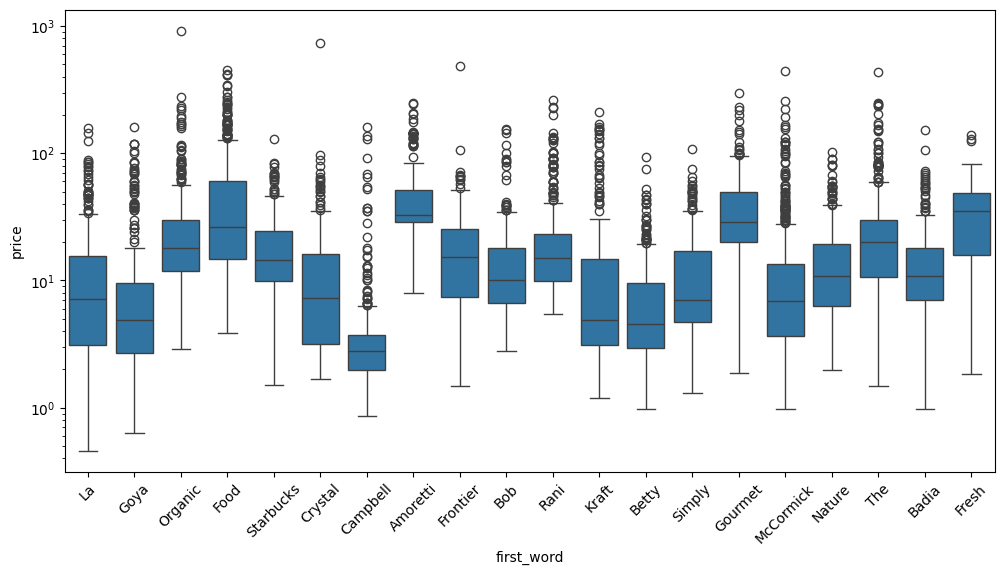

In [15]:
# crude brand/first-word extraction
train['first_word'] = train['catalog_content'].astype(str).str.extract(r'Item Name:\s*(\w+)')
top_brands = train['first_word'].value_counts().head(20)
print(top_brands)

# price variance by top brands
top_brand_list = top_brands.index.tolist()
subset = train[train['first_word'].isin(top_brand_list)]
plt.figure(figsize=(12,6))
sns.boxplot(x='first_word', y='price', data=subset)
plt.xticks(rotation=45)
plt.yscale('log')
plt.show()

In [16]:
import re
sample_texts = train['catalog_content'].sample(10, random_state=1)
for t in sample_texts:
    matches = re.findall(r'\d+\.?\d*\s*(oz|lb|g|kg|ml|l|count|pack|ct)\b', str(t), re.IGNORECASE)
    print(matches, '|', str(t)[:100])

['Pack'] | Item Name: Dill Rooibos Tea (50 tea bags, ZIN: 532431) - 3 Pack
Bullet Point 1: Our Dill Rooibos Tea
[] | Item Name: 7 UP A&W Cream Soda Soft Drink, 20-Ounce (Pack of 24)
Bullet Point 1: Cream Soda Flavor: 
['G'] | Item Name: Maldon Salt Smoked Sea Salt 125G Bundle Pack Of 2
Value: 1.0
Unit: Count

['oz'] | Item Name: D.ivina Organic Pitted Kalamata Olives 6 oz (Pack of 6)
Bullet Point 1: Versatile Use: Id
['Oz'] | Item Name: Roasted Salted Corn Nuts Snack with Sea Salt by Its Delish (4 lbs)
Bullet Point 1: SCRUMP
['Pack'] | Item Name: Stroop Club Caramel Delights Cookies | Organic Waffles and Plant Based | Vegan Healthy Sn
['Count', 'g', 'Pack', 'g'] | Item Name: Blake’s Seed Based Chewy Granola Bars — Variety Pack (24 Count), Vegan, Gluten Free, Nut 
['lb', 'oz'] | Item Name: Fresh Roasted Coffee, Fair Trade Organic Ethiopian Sidamo Water Decaf, 5 lb (80 oz), Kosh
['oz', 'oz', 'oz'] | Item Name: Kraft, Velveeta, Cheesy Bowls, 9oz Microwave Tray (Pack of 4) (Choose Flavors 

In [17]:
print("Train text len (words):", train['text_len_words'].describe())
print("Test text len (words):", test['catalog_content'].astype(str).apply(lambda x: len(x.split())).describe())

Train text len (words): count    75000.000000
mean       147.851693
std        137.068731
min          7.000000
25%         42.000000
50%        104.000000
75%        208.000000
max       1333.000000
Name: text_len_words, dtype: float64
Test text len (words): count    75000.000000
mean       148.145907
std        137.760572
min          7.000000
25%         42.000000
50%        103.000000
75%        210.000000
max       1928.000000
Name: catalog_content, dtype: float64


In [18]:
train['image_filesize'] = train['image_filename'].apply(
    lambda f: os.path.getsize(os.path.join(IMAGES_DIR, f)) if os.path.exists(os.path.join(IMAGES_DIR, f)) else np.nan
)
print(train['image_filesize'].corr(train['price']))
print(train['image_filesize'].corr(np.log1p(train['price'])))

-0.03485131996527821
-0.040125344805474465


In [19]:
import re
text = train['catalog_content'].astype(str)

# presence checks — now accounts for format variants
fields = {
    'Item Name': r'Item Name:|Item Name \d+:',
    'Bullet Point': r'Bullet Point \d+:|Bullet Point:',
    'Product Description': r'Product Description:',
    'Value': r'Value:\s*[\d.]+',
    'Unit': r'Unit:\s*\S+',
}

for name, pattern in fields.items():
    count = text.str.contains(pattern, regex=True, na=False).sum()
    print(f"{name}: {count} / {len(train)} ({100*count/len(train):.1f}%)")

# how many bullet points per row — handles numbered AND unnumbered bullets
def count_bullets(t):
    numbered = re.findall(r'Bullet Point (\d+):', t)
    if numbered:
        return max(int(m) for m in numbered)
    unnumbered = re.findall(r'Bullet Point:', t)
    return len(unnumbered)  # unnumbered case, just count occurrences

train['num_bullets'] = text.apply(count_bullets)
print("\nBullet point count distribution:")
print(train['num_bullets'].value_counts().sort_index())

Item Name: 75000 / 75000 (100.0%)
Bullet Point: 60723 / 75000 (81.0%)
Product Description: 32533 / 75000 (43.4%)
Value: 74060 / 75000 (98.7%)
Unit: 74999 / 75000 (100.0%)

Bullet point count distribution:
num_bullets
0     14277
1      6247
2      1893
3      4450
4      6681
5     35931
6      3272
7      1064
8       425
9       302
10      425
11       10
12        7
13        5
14        3
15        4
16        1
17        1
21        1
26        1
Name: count, dtype: int64


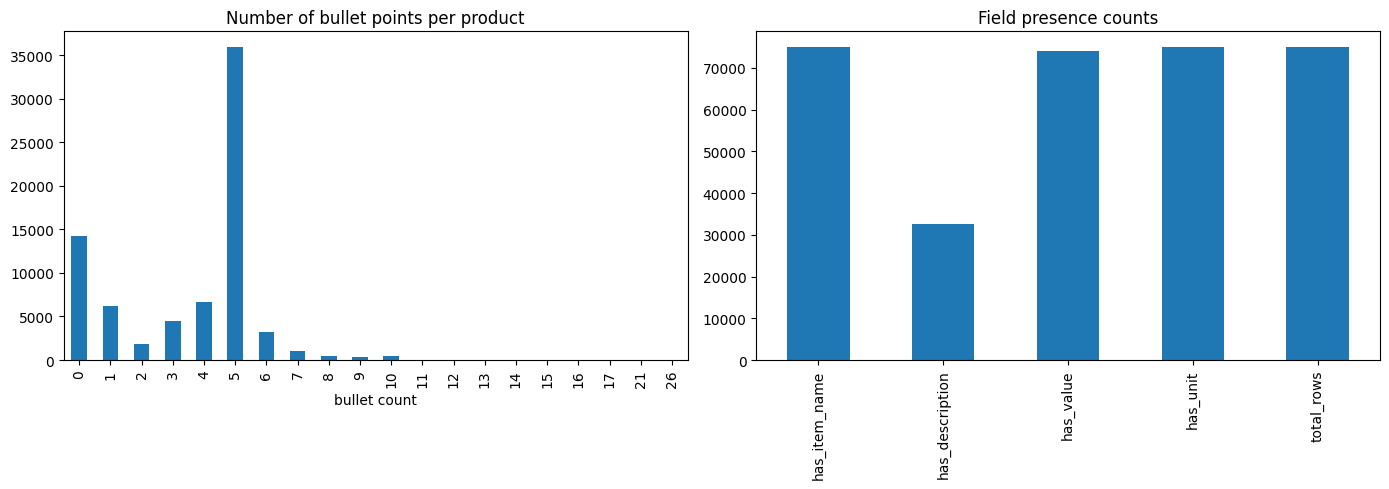

In [20]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14,5))
train['num_bullets'].value_counts().sort_index().plot(kind='bar', ax=axes[0])
axes[0].set_title('Number of bullet points per product')
axes[0].set_xlabel('bullet count')

has_desc = text.str.contains(r'Product Description:', na=False)
has_value = text.str.contains(r'Value:\s*[\d.]+', na=False)
has_unit = text.str.contains(r'Unit:\s*\S+', na=False)
has_item_name = text.str.contains(r'Item Name:|Item Name \d+:', na=False)

pd.Series({
    'has_item_name': has_item_name.sum(),
    'has_description': has_desc.sum(),
    'has_value': has_value.sum(),
    'has_unit': has_unit.sum(),
    'total_rows': len(train)
}).plot(kind='bar', ax=axes[1])
axes[1].set_title('Field presence counts')
plt.tight_layout()
plt.show()

In [21]:
# confirm which bullet counts exist at all
present_counts = sorted(train['num_bullets'].unique())
print("Bullet counts that occur:", present_counts)

all_possible = set(range(0, train['num_bullets'].max() + 1))
missing_counts = sorted(all_possible - set(present_counts))
print("\nBullet counts with zero occurrences:", missing_counts)

# rows with 21 bullet points
rows_21 = train[train['num_bullets'] == 21]
print("\n=== num_bullets == 21 ===")
print(rows_21[['sample_id']])
print("Index:", rows_21.index.tolist())

# rows with 26 bullet points
rows_26 = train[train['num_bullets'] == 26]
print("\n=== num_bullets == 26 ===")
print(rows_26[['sample_id']])
print("Index:", rows_26.index.tolist())

Bullet counts that occur: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(21), np.int64(26)]

Bullet counts with zero occurrences: [18, 19, 20, 22, 23, 24, 25]

=== num_bullets == 21 ===
       sample_id
29167     256707
Index: [29167]

=== num_bullets == 26 ===
       sample_id
11753      12722
Index: [11753]


In [22]:
train['catalog_content'][29167]

"Item Name: Reese's Eggs, White Peanut Butter, 7.2 Ounce\nBullet Point 1: REESE'S\nBullet Point 2: Kosher\nBullet Point 3: Easter\nBullet Point 4: Peanuts\nBullet Point 5: Sugar\nBullet Point 6: Vegetable Oil (Palm Oil, Shea Oil, Sunflower Oil, Palm Kernel Oil, Safflower Oil)\nBullet Point 7: Dextrose\nBullet Point 8: Skim Milk\nBullet Point 9: Corn Syrup Solids\nBullet Point 10: Lactose\nBullet Point 11: Contains 2% or Less of:\nBullet Point 12: Salt\nBullet Point 13: Hydrogenated Vegetable Oil (Palm Kernel Oil, Palm Oil)\nBullet Point 14: Corn Syrup\nBullet Point 15: Lecithin\nBullet Point 16: Cornstarch\nBullet Point 17: Glycerin\nBullet Point 18: TBHQ\nBullet Point 19: Citric Acid\nBullet Point 20: Vanillin\nBullet Point 21: PGPR\nProduct Description: This Easter, treat yourself to the sweet taste of a REESE’S White Creme Peanut Butter Egg. These egg-shaped peanut butter cups, enrobed in white Creme, are the perfect twist for Easter baskets and springtime snacking. REESE'S Kosher E

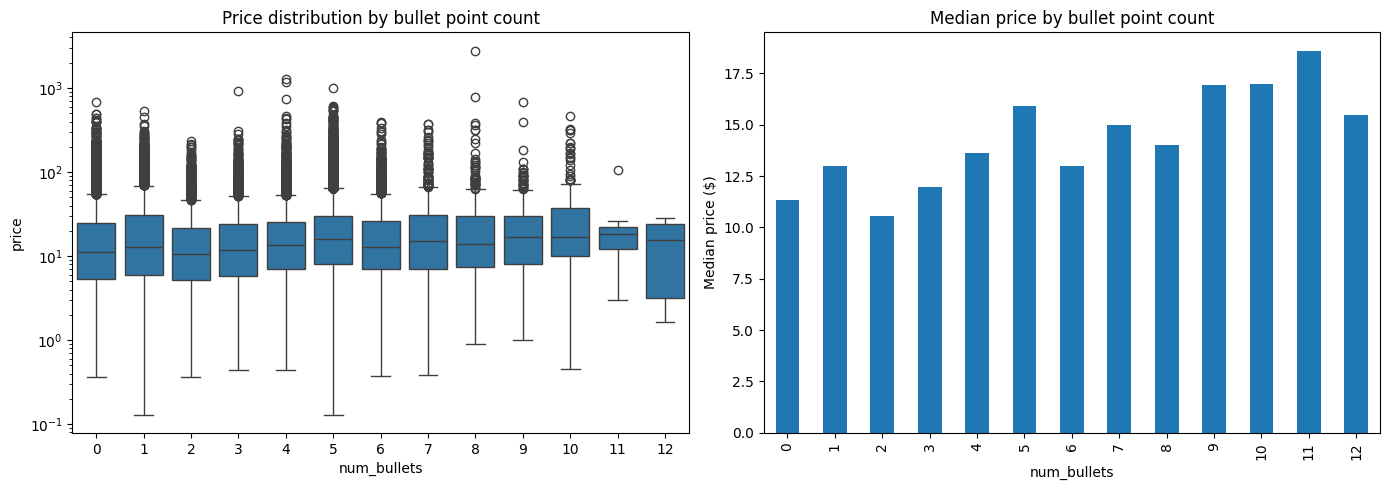

Correlation (num_bullets vs price): 0.02193311482732274
Correlation (num_bullets vs log price): 0.08063684481187122

Median price by bullet count:
num_bullets
0     11.3200
1     12.9700
2     10.5350
3     11.9500
4     13.6100
5     15.8900
6     12.9900
7     14.9750
8     13.9900
9     16.9475
10    16.9900
11    18.5675
12    15.4700
13     8.1500
14    13.9500
15    18.8850
16     7.9800
17     4.4900
21     5.9700
26    16.4300
Name: price, dtype: float64


In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot: price distribution per bullet count (capped to reasonable range for readability)
plot_data = train[train['num_bullets'] <= 12]  # tail beyond 12 is too sparse to show meaningfully
sns.boxplot(x='num_bullets', y='price', data=plot_data, ax=axes[0])
axes[0].set_yscale('log')
axes[0].set_title('Price distribution by bullet point count')

# Median price by bullet count (bar chart, cleaner trend view)
median_price_by_bullets = train.groupby('num_bullets')['price'].median()
median_price_by_bullets[median_price_by_bullets.index <= 12].plot(kind='bar', ax=axes[1])
axes[1].set_title('Median price by bullet point count')
axes[1].set_ylabel('Median price ($)')

plt.tight_layout()
plt.show()

print("Correlation (num_bullets vs price):", train['num_bullets'].corr(train['price']))
print("Correlation (num_bullets vs log price):", train['num_bullets'].corr(np.log1p(train['price'])))

print("\nMedian price by bullet count:")
print(median_price_by_bullets)

                 median       mean  count
has_description                          
False             10.99  19.471171  42467
True              18.19  29.099432  32533


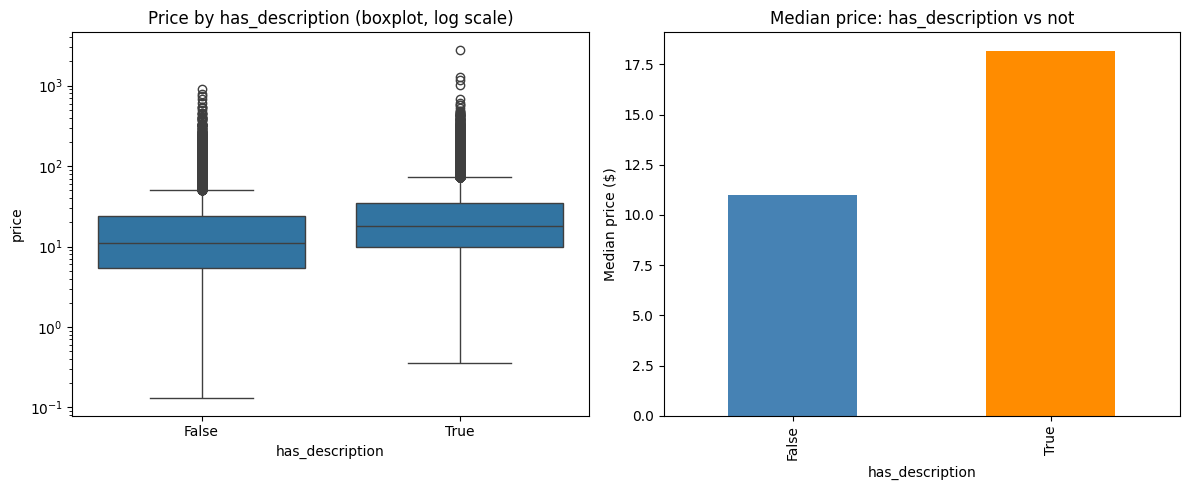

In [24]:
train['has_description'] = (train['description'] != '') if 'description' in train.columns else train['catalog_content'].astype(str).str.contains(r'Product Description:', na=False)

summary = train.groupby('has_description')['price'].agg(['median', 'mean', 'count'])
print(summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x='has_description', y='price', data=train, ax=axes[0])
axes[0].set_yscale('log')
axes[0].set_title('Price by has_description (boxplot, log scale)')

summary['median'].plot(kind='bar', ax=axes[1], color=['steelblue', 'darkorange'])
axes[1].set_title('Median price: has_description vs not')
axes[1].set_ylabel('Median price ($)')

plt.tight_layout()
plt.show()

In [25]:
train.columns

Index(['sample_id', 'catalog_content', 'image_link', 'price', 'image_filename',
       'text_len_chars', 'text_len_words', 'first_word', 'image_filesize',
       'num_bullets', 'has_description'],
      dtype='object')

In [26]:
derived_cols = [
    'text_len_chars', 'text_len_words', 'image_filename', 'first_word',
    'item_name', 'bullets_text', 'num_bullets', 'description',
    'value', 'unit', 'has_description', 'has_bullets', 'has_value'
]
existing = [c for c in derived_cols if c in train.columns]
if existing:
    train = train.drop(columns=existing)

In [27]:
import re
import numpy as np
import pandas as pd

def drop_derived_columns(df):
    derived_cols = [
        'text_len_chars', 'text_len_words', 'image_filename',
        'value', 'unit', 'has_description', 'has_bullets', 'has_value', 'num_bullets'
    ]
    existing = [c for c in derived_cols if c in df.columns]
    if existing:
        df = df.drop(columns=existing)
    return df


def extract_features(df, text_col='catalog_content', image_link_col='image_link'):
    """
    Adds lightweight numeric/categorical features WITHOUT splitting catalog_content.
    The raw catalog_content stays intact for direct embedding.
    """
    df = drop_derived_columns(df.copy())
    text = df[text_col].astype(str)

    df['text_len_chars'] = text.apply(len)
    df['text_len_words'] = text.apply(lambda x: len(x.split()))

    if image_link_col in df.columns:
        df['image_filename'] = df[image_link_col].apply(lambda x: str(x).split('/')[-1])

    # value & unit — light regex extraction, no full parsing
    df['value'] = text.str.extract(r'Value:\s*([\d.]+)').astype(float)
    df['unit'] = text.str.extract(r'Unit:\s*([^\n]+)')[0].str.strip()

    # bullet count — just a count, no need to extract text per-bullet
    df['num_bullets'] = text.apply(lambda t: len(re.findall(r'Bullet Point (\d+):', t)) or len(re.findall(r'Bullet Point:', t)))

    df['has_description'] = text.str.contains(r'Product Description:', na=False)
    df['has_bullets'] = df['num_bullets'] > 0
    df['has_value'] = df['value'].notna()

    return df

In [28]:
train_split = extract_features(train)
# val_split = extract_features(val_split)
# test_split = extract_features(test_split)
# official_test = extract_features(official_test)

train_split[['sample_id', 'catalog_content', 'value', 'unit', 'num_bullets',
             'has_description', 'has_bullets', 'has_value',
             'text_len_chars', 'text_len_words']].head(5)

,sample_id,catalog_content,value,unit,num_bullets,has_description,has_bullets,has_value,text_len_chars,text_len_words
0,33127,"Item Name: La Victoria Green Taco Sauce Mild, ...",72.00,Fl Oz,0,False,False,True,91,18
1,198967,"Item Name: Salerno Cookies, The Original Butte...",32.00,Ounce,5,False,True,True,511,80
2,261251,"Item Name: Bear Creek Hearty Soup Bowl, Creamy...",11.40,Ounce,5,False,True,True,328,59
3,55858,Item Name: Judee’s Blue Cheese Powder 11.25 oz...,11.25,Ounce,5,True,True,True,1318,211
4,292686,"Item Name: kedem Sherry Cooking Wine, 12.7 Oun...",12.00,Count,1,False,True,True,155,28


In [29]:
train_split.columns

Index(['sample_id', 'catalog_content', 'image_link', 'price', 'image_filesize',
       'text_len_chars', 'text_len_words', 'image_filename', 'value', 'unit',
       'num_bullets', 'has_description', 'has_bullets', 'has_value'],
      dtype='object')